<a href="https://colab.research.google.com/github/Notvishuuuu/SIH26175-DepthWizard-/blob/Suryansh-Calibration/Calibration_DEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!ls

absolute_elevation.npy	depth_visual.png   satellite_depth.npy
aligned_dem.npy		masked_depth.npy   satellite_image.tif
Calibration_DEM.ipynb	metadata.json	   SIH26175-DepthWizard-
Depth_Analysis.ipynb	nyc_dem.tif	   src
depth.npy		reference_dem.tif


In [ ]:
!wget https://raw.githubusercontent.com/rasterio/rasterio/master/tests/data/RGB.byte.tif -O satellite_image.tif

--2026-09-05 14:06:50--  https://raw.githubusercontent.com/rasterio/rasterio/master/tests/data/RGB.byte.tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1745956 (1.7M) [image/tiff]
Saving to: ‘satellite_image.tif’

satellite_image.tif 100%[===================>]   1.67M  --.-KB/s    in 0.1s    

2026-09-05 14:06:51 (13.0 MB/s) - ‘satellite_image.tif’ saved [1745956/1745956]



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import rasterio
from rasterio.warp import transform_bounds

# Open the satellite image
with rasterio.open("satellite_image.tif") as src:
    # Transform the bounds from the image's native CRS to WGS84 (Lat/Lon degrees)
    west, south, east, north = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)

    print(f"West: {west}\nSouth: {south}\nEast: {east}\nNorth: {north}")

West: -78.95864996539397
South: 23.564991210892646
East: -76.57492370013779
North: 25.550873767434343


In [ ]:
from google.colab import userdata
import requests

# Load your existing API key
API_KEY = userdata.get("OPENTOPOGRAPHY_API_KEY")

url = "https://portal.opentopography.org/API/globaldem"
params = {
    "demtype": "SRTMGL1",
    "south": south,
    "north": north,
    "west": west,
    "east": east,
    "outputFormat": "GTiff",
    "API_Key": API_KEY,
}

print("Downloading DEM...")
response = requests.get(url, params=params)

# Save the downloaded elevation data
with open("reference_dem.tif", "wb") as f:
    f.write(response.content)

print("DEM saved as reference_dem.tif")

DEM saved as reference_dem.tif


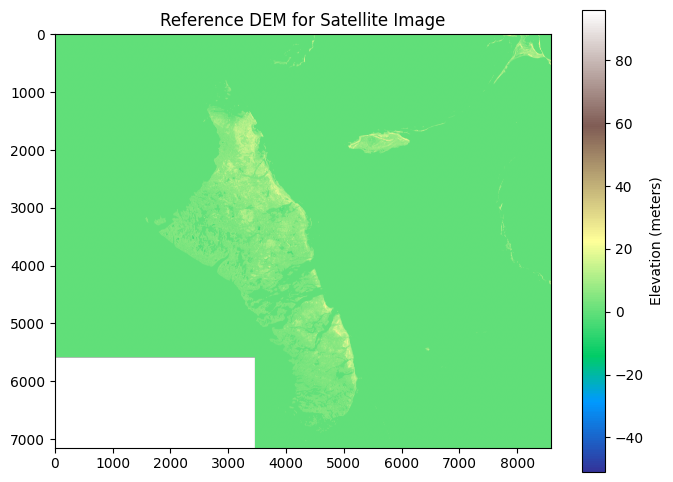

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

with rasterio.open("reference_dem.tif") as src:
    dem = src.read(1)
    # Handle nodata values by replacing them with NaN for visualization
    nodata = src.nodata
    if nodata is not None:
        dem = np.where(dem == nodata, np.nan, dem)

plt.figure(figsize=(8, 6))
plt.imshow(dem, cmap="terrain")
plt.colorbar(label="Elevation (meters)")
plt.title("Reference DEM for Satellite Image")
plt.show()

Loading model...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

Generating relative depth map...
Depth map saved! Shape: (718, 791)
Min depth: 0.6115, Max depth: 4.9610


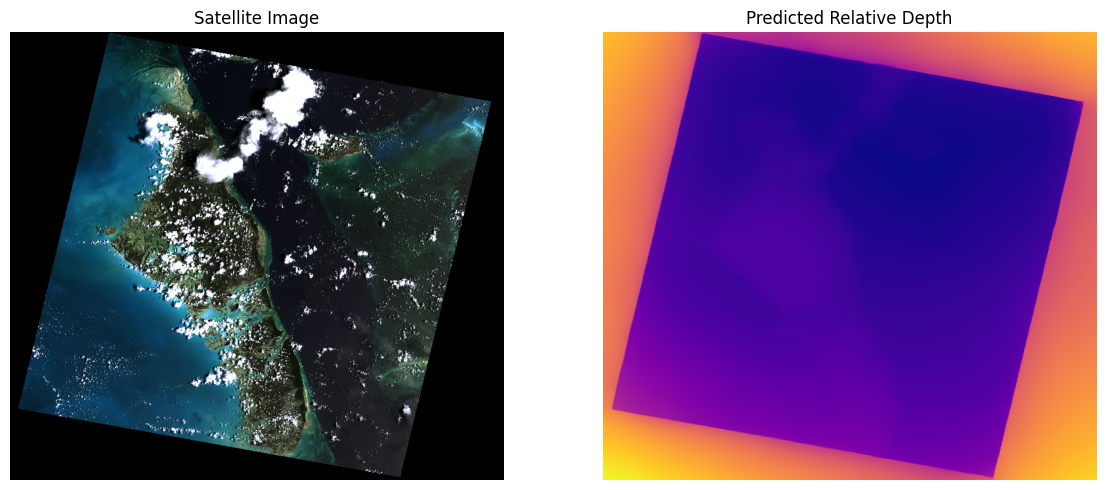

In [ ]:
# Install/Update transformers just to be safe
!pip install -q transformers

from transformers import pipeline
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1. Load the Depth Anything V2 pipeline
print("Loading model...")
pipe = pipeline(task="depth-estimation", model="depth-anything/Depth-Anything-V2-Small-hf")

# 2. Open the satellite image and ensure it is in RGB format
image = Image.open("satellite_image.tif").convert('RGB')
original_size = (image.height, image.width)

# 3. Run inference
print("Generating relative depth map...")
result = pipe(image)

# 4. Extract raw float values and format dimensions for 2D interpolation
raw_depth = result["predicted_depth"]

# PyTorch interpolate needs a 4D tensor: (Batch, Channel, Height, Width)
if isinstance(raw_depth, torch.Tensor):
    while raw_depth.ndim < 4:
        raw_depth = raw_depth.unsqueeze(0)
else:
    # If the pipeline returned a PIL image or numpy array
    raw_depth = torch.from_numpy(np.array(raw_depth)).float()
    while raw_depth.ndim < 4:
        raw_depth = raw_depth.unsqueeze(0)

# Resize to match original image dimensions
depth_resized = torch.nn.functional.interpolate(
    raw_depth,
    size=original_size,
    mode="bicubic",
    align_corners=False
)

# Convert to a standard 2D NumPy array
depth_array = depth_resized.squeeze().cpu().numpy()

# 5. Save the result
np.save("satellite_depth.npy", depth_array)
print(f"Depth map saved! Shape: {depth_array.shape}")
print(f"Min depth: {depth_array.min():.4f}, Max depth: {depth_array.max():.4f}")

# 6. Visualize the output
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title("Satellite Image")
axes[0].axis("off")

axes[1].imshow(depth_array, cmap="plasma")
axes[1].set_title("Predicted Relative Depth")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Alignment complete!
Aligned DEM shape: (718, 791)


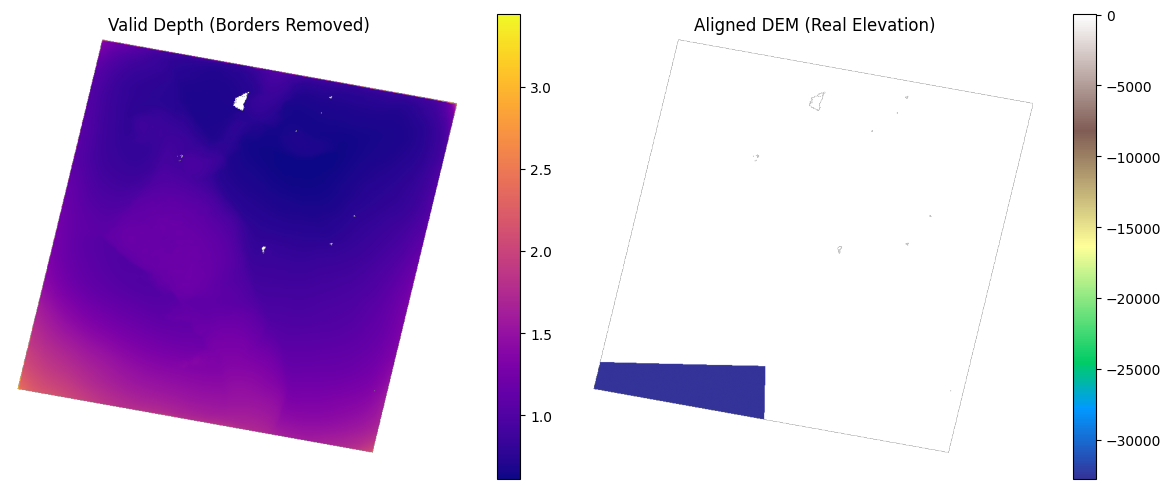

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

# 1. Load your newly generated relative depth map
depth_array = np.load("satellite_depth.npy")

# 2. Open the satellite image to get its exact spatial grid and find the black borders
with rasterio.open("satellite_image.tif") as sat_src:
    sat_transform = sat_src.transform
    sat_crs = sat_src.crs
    sat_shape = (sat_src.height, sat_src.width)
    sat_rgb = sat_src.read() # Read the color bands

# Create a mask to keep only valid pixels (ignore black borders where R=0, G=0, B=0)
valid_mask = np.any(sat_rgb > 0, axis=0)

# 3. Open the downloaded DEM and warp it to match the satellite image exactly
with rasterio.open("reference_dem.tif") as dem_src:
    # Create an empty array to hold the reshaped DEM
    aligned_dem = np.zeros(sat_shape, dtype=np.float32)

    # Reproject (resize and align) the DEM onto the satellite image's grid
    reproject(
        source=rasterio.band(dem_src, 1),
        destination=aligned_dem,
        src_transform=dem_src.transform,
        src_crs=dem_src.crs,
        dst_transform=sat_transform,
        dst_crs=sat_crs,
        resampling=Resampling.bilinear
    )

# 4. Apply the mask so we ignore the black borders in both arrays
masked_depth = np.where(valid_mask, depth_array, np.nan)
masked_dem = np.where(valid_mask, aligned_dem, np.nan)

# Save the perfectly matched arrays for our final math step
np.save("aligned_dem.npy", masked_dem)
np.save("masked_depth.npy", masked_depth)

print("Alignment complete!")
print(f"Aligned DEM shape: {aligned_dem.shape}")

# 5. Visualize the perfectly aligned, masked data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Valid Depth
im1 = axes[0].imshow(masked_depth, cmap="plasma")
axes[0].set_title("Valid Depth (Borders Removed)")
axes[0].axis("off")
plt.colorbar(im1, ax=axes[0])

# Plot Aligned DEM
im2 = axes[1].imshow(masked_dem, cmap="terrain")
axes[1].set_title("Aligned DEM (Real Elevation)")
axes[1].axis("off")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

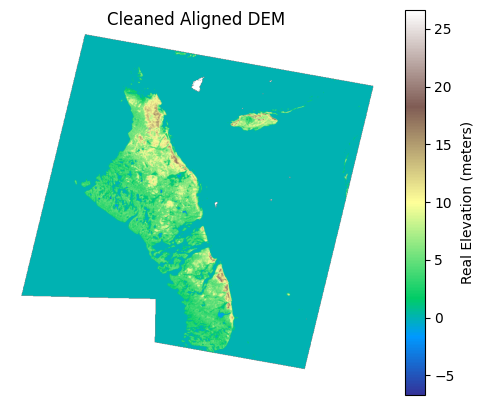

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned arrays we just saved
masked_depth = np.load("masked_depth.npy")
masked_dem = np.load("aligned_dem.npy")

# Create a new mask that ignores extreme NoData values in the DEM (anything below -100m)
valid_dem_mask = (masked_dem > -100) & (masked_dem < 9000)

# Combine masks: Keep only pixels that have BOTH valid depth AND valid DEM elevation
# The ~np.isnan safely handles the NaNs we placed in the previous step
final_mask = (~np.isnan(masked_depth)) & (~np.isnan(masked_dem)) & valid_dem_mask

# Apply the strict final mask
clean_depth = np.where(final_mask, masked_depth, np.nan)
clean_dem = np.where(final_mask, masked_dem, np.nan)

# Visualize the fixed DEM
plt.figure(figsize=(6, 5))
plt.imshow(clean_dem, cmap="terrain")
plt.colorbar(label="Real Elevation (meters)")
plt.title("Cleaned Aligned DEM")
plt.axis("off")
plt.show()

Training calibration model on 362946 pixels...
Success! Formula: Real Elevation = (0.66 * Relative Depth) + 0.28
Saved final height map as 'absolute_elevation.npy' in real meters!


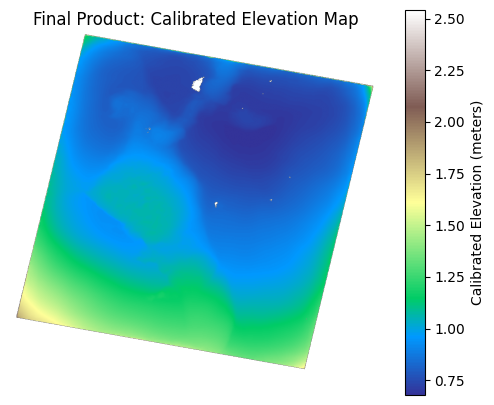

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Flatten the arrays and extract only the valid pixels for math
X = clean_depth[final_mask].reshape(-1, 1)  # The relative depth values
y = clean_dem[final_mask]                   # The real elevation values

print(f"Training calibration model on {len(y)} pixels...")

# 2. Fit the linear regression model: Real Elevation = (a * Depth) + b
model = LinearRegression()
model.fit(X, y)

a = model.coef_[0]
b = model.intercept_

print(f"Success! Formula: Real Elevation = ({a:.2f} * Relative Depth) + {b:.2f}")

# 3. Apply the formula to your ENTIRE depth map to convert it to meters
original_depth_array = np.load("satellite_depth.npy")
absolute_elevation_map = (original_depth_array * a) + b

# Apply our original border mask to keep the edges clean
absolute_elevation_map = np.where(~np.isnan(masked_depth), absolute_elevation_map, np.nan)

# Save the final product for your 3D visualization team!
np.save("absolute_elevation.npy", absolute_elevation_map)
print("Saved final height map as 'absolute_elevation.npy' in real meters!")

# 4. Final Visual Check
plt.figure(figsize=(6, 5))
plt.imshow(absolute_elevation_map, cmap="terrain")
plt.colorbar(label="Calibrated Elevation (meters)")
plt.title("Final Product: Calibrated Elevation Map")
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files

# Download the final calibrated elevation map
files.download('absolute_elevation.npy')

# Download the satellite image
files.download('satellite_image.tif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>